# Super Mario RL - Balanced Final

**修正懲罰機制太嚴苛所以太怕死的問題**
1. **死亡懲罰 -100**：回到適中的懲罰，不再讓 AI 嚇到不敢動。
2. **移動獎勵 2.0**：足夠的誘因讓他想往右衝。
3. **RIGHT_ONLY**：強迫往右，保證不卡關。


**執行順序**
1. 執行 **[Cell 1]** 安裝環境。
2. **點擊 [重新啟動工作階段]**。
3. 跳過 [Cell 1]，從 **[Cell 2]** 開始執行到底。


**研究背景**

參考許多社群訓練經驗，了解到訓練關鍵在於獎勵函數的設計
像是不能設計死亡懲罰機制太過嚴苛或寬鬆


**大致設計機制思路說明**

- SkipFrame 最佳化說明：使用每 4 幀跳過一次的技術提升訓練效率，更重要的是提供動作連續性，讓 AI 學會預判畫面變動
- 模型架構升級：選用 Dueling DQN 而非傳統 CNN，透過分離狀態價值與動作優勢，模型能更穩定處理瑪利歐在空中的決策
- 修正消極避險：原本懲罰太重（-500）導致 AI 怕死不動的實驗觀察，嘗試多次才下調至 -100 又不過於寬鬆
- Goomba 觀察與修正：記錄 AI 原本只想跳過水管卻被敵人撞死的狀況。透過加入 score_diff 權重，誘導 AI 從逃避轉向主動壓扁敵人
- 電擊療法：解釋人為調高探索率（Epsilon Boost）的邏輯，強迫 AI 走出舒適圈尋找更優路徑

In [2]:
# [Cell 1] 環境建置 (執行後請重啟 Runtime)
!pip install gym==0.25.2
!pip install nes-py==8.2.1
!pip install gym-super-mario-bros==7.4.0
!pip install pyvirtualdisplay
!pip install torch torchvision opencv-python matplotlib tqdm
!pip install "numpy<2.0"
!apt-get update > /dev/null 2>&1
!apt-get install -y xvfb python-opengl ffmpeg > /dev/null 2>&1

import os, site
def patch_nes_py():
    site_packages = site.getsitepackages()
    target_file = None
    for path in site_packages:
        search_path = os.path.join(path, "nes_py", "_rom.py")
        if os.path.exists(search_path):
            target_file = search_path
            break
    if target_file:
        with open(target_file, "r") as f: content = f.read()
        old_code = "return self.prg_rom_start + self.prg_rom_size * 2**10"
        new_code = "return self.prg_rom_start + int(self.prg_rom_size) * 2**10"
        if old_code in content:
            content = content.replace(old_code, new_code)
            with open(target_file, "w") as f: f.write(content)
            print(f"OverflowError 修復完成: {target_file}")
patch_nes_py()
print("\n 環境安裝完成！請點擊 [重新啟動工作階段]，然後繼續。")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.7/77.7 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 76.6 MB/s eta 0:00:00
  Created wheel for nes-py: filename=nes_py-8.2.1-cp312-cp312-linux_x86_64.whl size=535721 sha256=0e528ca150a49a2965bfb4d6875fc1c4df5247cb02a4a367c2d07c64672e4474
  Stored in directory: /root/.cache/pip/wheels/1f/a7/fa/9b0357f258d2e68bdc71df972e02418bceb02355ac1f365c59
Successfully built nes-py
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 16.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 137.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behav

OverflowError 修復完成: /usr/local/lib/python3.12/dist-packages/nes_py/_rom.py

 環境安裝完成！請點擊 [重新啟動工作階段]，然後繼續。


In [1]:
# [Cell 2] 啟動與匯入
from pyvirtualdisplay import Display
display = Display(visible=0, size=(1400, 900))
display.start()

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import cv2
import random
from collections import deque
from tqdm.notebook import tqdm
import gym_super_mario_bros
from nes_py.wrappers import JoypadSpace
from gym_super_mario_bros.actions import RIGHT_ONLY
import gym
import matplotlib.pyplot as plt
import os
import collections
import collections.abc

if not hasattr(collections, 'Iterable'): collections.Iterable = collections.abc.Iterable

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [2]:
# [Cell 3] 影像處理
class SkipFrame(gym.Wrapper):
    def __init__(self, env, skip):
        super().__init__(env)
        self._skip = skip

    def step(self, action):
        total_reward = 0.0
        done = False
        info = {}
        for _ in range(self._skip):
            next_state, reward, done, info = self.env.step(action)
            total_reward += reward
            if done:
                break
        return next_state, total_reward, done, info

def preprocess_frame(frame):
    if frame is not None:
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
        frame = cv2.resize(frame, (84, 84))
        frame = frame.astype(np.float32) / 255.0
        return frame
    return np.zeros((84, 84), np.float32)

def save_video(frames, filename, fps=30.0):
    if not frames: return
    h, w, _ = frames[0].shape
    out = cv2.VideoWriter(filename, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    for f in frames: out.write(cv2.cvtColor(f, cv2.COLOR_RGB2BGR))
    out.release()
    print(f"Video saved: {filename}")

In [3]:
# [Cell 4] Dueling DQN Model
class DuelingCNN(nn.Module):
    def __init__(self, input_shape, num_actions):
        super(DuelingCNN, self).__init__()
        c, _, _ = input_shape
        self.conv = nn.Sequential(
            nn.Conv2d(c, 32, 8, 4), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2), nn.ReLU(),
            nn.Conv2d(64, 64, 3, 1), nn.ReLU()
        )
        feat_size = 64 * 7 * 7
        self.fc_val = nn.Sequential(nn.Linear(feat_size, 512), nn.ReLU(), nn.Linear(512, 1))
        self.fc_adv = nn.Sequential(nn.Linear(feat_size, 512), nn.ReLU(), nn.Linear(512, num_actions))

    def forward(self, x):
        x = self.conv(x).view(x.size(0), -1)
        val = self.fc_val(x)
        adv = self.fc_adv(x)
        return val + (adv - adv.mean(dim=1, keepdim=True))

In [4]:
# [Cell 5] Agent
class ReplayMemory:
    def __init__(self, capacity): self.memory = deque(maxlen=capacity)
    def push(self, *args): self.memory.append(args)
    def sample(self, batch_size): return zip(*random.sample(self.memory, batch_size))
    def __len__(self): return len(self.memory)

class DoubleDQN_Agent:
    def __init__(self, state_dim, action_dim, lr, gamma, epsilon, target_update, device):
        self.device, self.action_dim = device, action_dim
        self.gamma, self.epsilon, self.target_update = gamma, epsilon, target_update
        self.update_count = 0

        self.policy_net = DuelingCNN(state_dim, action_dim).to(device)
        self.target_net = DuelingCNN(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        with torch.no_grad():
            state_np = np.array([state])
            return self.policy_net(torch.tensor(state_np, dtype=torch.float32, device=self.device)).argmax().item()

    def train(self, memory, batch_size):
        if len(memory) < batch_size: return
        states, actions, rewards, next_states, dones = memory.sample(batch_size)

        s = torch.tensor(np.stack(states), dtype=torch.float32, device=self.device)
        a = torch.tensor(actions, dtype=torch.long, device=self.device).unsqueeze(1)
        r = torch.tensor(rewards, dtype=torch.float32, device=self.device)
        ns = torch.tensor(np.stack(next_states), dtype=torch.float32, device=self.device)
        d = torch.tensor(dones, dtype=torch.float32, device=self.device)

        next_actions = self.policy_net(ns).argmax(1, keepdim=True)
        next_q = self.target_net(ns).gather(1, next_actions).squeeze(1)
        q_target = r + self.gamma * next_q * (1 - d)
        q_eval = self.policy_net(s).gather(1, a).squeeze(1)

        loss = nn.MSELoss()(q_eval, q_target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.update_count += 1
        if self.update_count % self.target_update == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

## reward 機制：
- 進度獎勵（水平位移）
    - 只要 x_pos 有往右增加，就給正回饋，而且把係數拉高到 2.0。讓前進成為最主要的價值來源，避免只求苟活
- 分數差異（score diff）作為進攻性引導
    - 只要 score 增加，就用 0.1 的權重給正回饋。讓 AI 理解踩怪、拿分並不是風險，而是收益
- 擊殺/大分事件額外加成
    - 當 score_diff ≥ 100 時，再額外加 25。強化成功踩怪這種關鍵事件的學習訊號，避免被連續小回饋淹沒
- 金幣獎勵
    - coins 增加就 +10。鼓勵探索與路徑推進，讓 AI 願意往前吃資源而不是縮在原地
- 死亡懲罰平衡
    - life 減少就 -100。這是我從失敗版本修正而來：早期用 -500 會把 AI 嚇到原地不動。最後我改成不輕不重的 -100，讓它怕死但不至於放棄探索
- 卡住懲罰（stuck penalty）
    - 如果 x_diff ≤ 0 就累積 steps_stuck，超過 20 步開始每步額外 -2。直接打破卡在水管、牆邊或局部最佳解的停滯行為。我一開始嘗試過更長的門檻，後來發現早一點介入更能逼它重新嘗試跳躍或換節奏
- 過關旗幟獎勵
    - flag_get 就 +500。動機是給終局目標，一個明確的大獎勵，讓策略不只追求局部小分
- 時間成本（living cost）
    - 每一步固定 -0.1。動機是避免無限猶豫，鼓勵更有效率地推進

In [5]:
# [Cell 6] 獎勵函數 (綜合平衡版)
def calculate_balanced_reward(info, reward, prev_info, done, steps_stuck):
    custom_reward = 0.0
    x_diff = info['x_pos'] - prev_info['x_pos']

    # 1. 速度：2.0 (給足夠誘因，讓他想跑)
    if x_diff > 0: custom_reward += x_diff * 2.0

    # 2. 踩扁 Goomba / turtle：給大一點的獎勵，讓他知道跳躍攻擊是好事
    score_diff = info['score'] - prev_info['score']
    if score_diff > 0:
        custom_reward += score_diff * 0.1
        if score_diff >= 100: custom_reward += 25.0
    if info['coins'] > prev_info['coins']: custom_reward += 10.0

    # 3. 死亡：回到 -100 (不輕不重，剛好怕死)
    if info['life'] < prev_info['life']: custom_reward -= 100.0

    # 4. 卡住懲罰
    if x_diff <= 0:
        steps_stuck += 1
        if steps_stuck > 20: custom_reward -= 2.0
    else: steps_stuck = 0

    if info['flag_get']: custom_reward += 500.0
    custom_reward -= 0.1
    return custom_reward, steps_stuck

/usr/local/lib/python3.12/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment SuperMarioBros-1-1-v0 is out of date. You should consider upgrading to version `v3`.
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-a

  0%|          | 0/1000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/gym/core.py:43: DeprecationWarning: WARN: The argument mode in render method is deprecated; use render_mode during environment initialization instead.
See here for more information: https://www.gymlibrary.ml/content/api/
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/utils/passive_env_checker.py:280: UserWarning: WARN: No render modes was declared in the environment (env.metadata['render_modes'] is None or not defined), you may have trouble when calling `.render()`.
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gym/utils/passive_env_checker.py:227: DeprecationWarning: WARN: Core environment is written in old step API which returns one bool instead of two. It is recommended to rewrite the environment with new step API. 
  logger.deprecation(
/usr/local/lib/python3.12/dist-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinsta

Start Balanced Training...
Video saved: ./videos_balanced_train/train_ep_1_R234.mp4
Video saved: ./videos_balanced_train/train_ep_20_R624.mp4
Video saved: ./videos_balanced_train/train_ep_40_R1391.mp4
Video saved: ./videos_balanced_train/train_ep_60_R624.mp4
Video saved: ./videos_balanced_train/train_ep_80_R1264.mp4
Video saved: ./videos_balanced_train/train_ep_100_R624.mp4
Video saved: ./videos_balanced_train/train_ep_120_R587.mp4
Video saved: ./videos_balanced_train/train_ep_140_R616.mp4
Video saved: ./videos_balanced_train/train_ep_160_R2226.mp4
Video saved: ./videos_balanced_train/train_ep_180_R1400.mp4
Video saved: ./videos_balanced_train/train_ep_200_R618.mp4
Video saved: ./videos_balanced_train/train_ep_220_R1786.mp4
Video saved: ./videos_balanced_train/train_ep_240_R-1020.mp4
Video saved: ./videos_balanced_train/train_ep_260_R610.mp4
Video saved: ./videos_balanced_train/train_ep_280_R1380.mp4
Video saved: ./videos_balanced_train/train_ep_300_R1473.mp4
Video saved: ./videos_bala

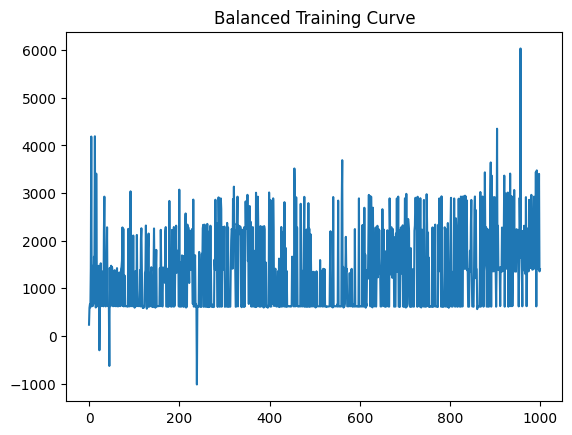

Training Complete!


In [6]:
# [Cell 7] 訓練主程式

LEARN_FREQ = 4
BATCH_SIZE = 256
MEMORY_SIZE = 80000
LR = 0.00025
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.95 # 慢慢衰減，多試幾次
TARGET_UPDATE = 1000
TOTAL_EPISODES = 1000

env = gym_super_mario_bros.make('SuperMarioBros-1-1-v0')
env = JoypadSpace(env, RIGHT_ONLY)
env = SkipFrame(env, skip=4)

agent = DoubleDQN_Agent((4, 84, 84), len(RIGHT_ONLY), LR, GAMMA, EPSILON_START, TARGET_UPDATE, device)
memory = ReplayMemory(MEMORY_SIZE)

if not os.path.exists('./videos_balanced_train'): os.makedirs('./videos_balanced_train')

pbar = tqdm(range(1, TOTAL_EPISODES + 1))
rewards = []
best_r = -float('inf')
total_steps = 0

print("Start Balanced Training...")

for ep in pbar:
    s = preprocess_frame(env.reset())
    state = np.concatenate([np.expand_dims(s, 0)]*4, 0)

    done, total_r, steps_stuck = False, 0, 0
    prev_info = {"x_pos": 0, "y_pos": 0, "score": 0, "coins": 0, "life": 2, "flag_get": False}
    frames = []

    should_record = (ep % 20 == 0) or (ep == 1)
    if should_record: frames.append(np.copy(env.render(mode='rgb_array')))

    while not done:
        total_steps += 1
        action = agent.select_action(state)
        res = env.step(action)
        next_raw, r, done, info = res if len(res)==4 else (res[0], res[1], res[2] or res[3], res[4])

        if should_record: frames.append(np.copy(next_raw))

        r_custom, steps_stuck = calculate_balanced_reward(info, r, prev_info, done, steps_stuck)
        total_r += r_custom

        ns = np.concatenate([state[1:], np.expand_dims(preprocess_frame(next_raw), 0)], 0)
        memory.push(state, action, r_custom, ns, done)
        state = ns
        prev_info = info

        if total_steps % LEARN_FREQ == 0 and len(memory) > BATCH_SIZE:
            agent.train(memory, BATCH_SIZE)

    if agent.epsilon > EPSILON_END: agent.epsilon *= EPSILON_DECAY
    rewards.append(total_r)
    pbar.set_description(f"Ep {ep} | R: {total_r:.1f} | Eps: {agent.epsilon:.2f}")

    if should_record: save_video(frames, f"./videos_balanced_train/train_ep_{ep}_R{int(total_r)}.mp4")

    # 只要有進步就存檔
    if total_r > best_r:
        best_r = total_r
        torch.save(agent.policy_net.state_dict(), "mario_balanced_best.pth")

    if ep % 50 == 0:
        torch.save(agent.policy_net.state_dict(), f"mario_balanced_ep_{ep}.pth")

env.close()
plt.plot(rewards); plt.title("Balanced Training Curve"); plt.show()
print("Training Complete!")

In [7]:
import os
import glob
import torch
import torch.nn as nn
import numpy as np
import cv2
import gym
import gym_super_mario_bros
from nes_py.wrappers import JoypadSpace
from gym_super_mario_bros.actions import RIGHT_ONLY, SIMPLE_MOVEMENT
import collections
import collections.abc

# 1. 基礎環境修補
if not hasattr(collections, 'Iterable'): collections.Iterable = collections.abc.Iterable

# 2. 定義必要的類別 (確保即使前面 Cell 沒跑也能運作)
class SkipFrame(gym.Wrapper):
    def __init__(self, env, skip):
        super().__init__(env)
        self._skip = skip
    def step(self, action):
        total_reward = 0.0
        done = False
        info = {}
        for _ in range(self._skip):
            next_state, reward, done, info = self.env.step(action)
            total_reward += reward
            if done: break
        return next_state, total_reward, done, info

def preprocess_frame(frame):
    if frame is not None:
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
        frame = cv2.resize(frame, (84, 84))
        frame = frame.astype(np.float32) / 255.0
        return frame
    return np.zeros((84, 84), np.float32)

class DuelingCNN(nn.Module):
    def __init__(self, input_shape, num_actions):
        super(DuelingCNN, self).__init__()
        c, _, _ = input_shape
        self.conv = nn.Sequential(
            nn.Conv2d(c, 32, 8, 4), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2), nn.ReLU(),
            nn.Conv2d(64, 64, 3, 1), nn.ReLU()
        )
        feat_size = 64 * 7 * 7
        self.fc_val = nn.Sequential(nn.Linear(feat_size, 512), nn.ReLU(), nn.Linear(512, 1))
        self.fc_adv = nn.Sequential(nn.Linear(feat_size, 512), nn.ReLU(), nn.Linear(512, num_actions))
    def forward(self, x):
        x = self.conv(x).view(x.size(0), -1)
        val = self.fc_val(x)
        adv = self.fc_adv(x)
        return val + (adv - adv.mean(dim=1, keepdim=True))

class DoubleDQN_Agent:
    def __init__(self, state_dim, action_dim, device):
        self.device = device
        self.policy_net = DuelingCNN(state_dim, action_dim).to(device)
        self.epsilon = 0.05
    def select_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(0, action_dim)
        with torch.no_grad():
            state_np = np.array([state])
            return self.policy_net(torch.tensor(state_np, dtype=torch.float32, device=self.device)).argmax().item()

def save_video(frames, filename, fps=30.0):
    if not frames: return
    h, w, _ = frames[0].shape
    out = cv2.VideoWriter(filename, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    for f in frames: out.write(cv2.cvtColor(f, cv2.COLOR_RGB2BGR))
    out.release()
    print(f"Video saved: {filename}")

# 3. 初始化環境與 Agent
print("正在初始化環境...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
env = gym_super_mario_bros.make('SuperMarioBros-1-1-v0')
# 嘗試使用 RIGHT_ONLY，因為你的最終版本是用這個
env = JoypadSpace(env, RIGHT_ONLY)
env = SkipFrame(env, skip=4)
action_dim = len(RIGHT_ONLY)
agent = DoubleDQN_Agent((4, 84, 84), action_dim, device)

# 4. 自動尋找並載入權重
print("正在搜尋權重檔 (.pth)...")
best_model = "mario_balanced_best.pth"

if best_model:
    try:
        agent.policy_net.load_state_dict(torch.load(best_model, map_location=device))
        print(f"成功載入模型 {best_model} 權重！")
    except RuntimeError as e:
        print(f"載入失敗，嘗試切換動作空間 (SIMPLE_MOVEMENT)...")
        # 如果因為動作空間不合導致載入失敗，切換回 SIMPLE_MOVEMENT 重試
        env.close()
        env = gym_super_mario_bros.make('SuperMarioBros-1-1-v0')
        env = JoypadSpace(env, SIMPLE_MOVEMENT)
        env = SkipFrame(env, skip=4)
        action_dim = len(SIMPLE_MOVEMENT)
        agent = DoubleDQN_Agent((4, 84, 84), action_dim, device)
        try:
            agent.policy_net.load_state_dict(torch.load(best_model, map_location=device))
            print("成功載入模型權重 (SIMPLE_MOVEMENT 模式)！")
        except Exception as e2:
            print(f"二次載入也失敗：{e2}")

# 5. 開始錄影
print("開始錄測試影片...")
video_dir = './videos_final'
if not os.path.exists(video_dir): os.makedirs(video_dir)

agent.epsilon = 0.05 # 測試時保留一點點隨機性，以免每次都卡死在同一個地方

for ep in range(1, 11):
    s = preprocess_frame(env.reset())
    state = np.concatenate([np.expand_dims(s, 0)]*4, 0)
    done = False
    frames = []

    # Render protection
    try: frames.append(np.copy(env.render(mode='rgb_array')))
    except: pass

    info = {'score': 0, 'x_pos': 0}

    # 為了防止記憶體爆掉，我們限制最大步數，如果卡太久就強制結束
    max_steps = 2000
    step_count = 0

    while not done and step_count < max_steps:
        action = agent.select_action(state)
        res = env.step(action)
        next_raw, r, done, info = res if len(res)==4 else (res[0], res[1], res[2] or res[3], res[4])

        # 每隔 2 幀存一次圖片，節省記憶體，但影片看起來還是流暢的
        if step_count % 2 == 0:
            frames.append(np.copy(next_raw))

        ns = np.concatenate([state[1:], np.expand_dims(preprocess_frame(next_raw), 0)], 0)
        state = ns
        step_count += 1

    save_video(frames, f"{video_dir}/test_ep_{ep}_score_{info.get('score', 0)}.mp4")
    print(f"Episode {ep} Done. Score: {info.get('score', 0)} Distance: {info.get('x_pos', 0)}")

    # 清空記憶體
    del frames

print(f"全部完成！請下載 {video_dir} 資料夾。")

正在初始化環境...


/usr/local/lib/python3.12/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment SuperMarioBros-1-1-v0 is out of date. You should consider upgrading to version `v3`.
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


正在搜尋權重檔 (.pth)...
成功載入模型 mario_balanced_best.pth 權重！
開始錄測試影片...
Video saved: ./videos_final/test_ep_1_score_100.mp4
Episode 1 Done. Score: 100 Distance: 898
Video saved: ./videos_final/test_ep_2_score_100.mp4
Episode 2 Done. Score: 100 Distance: 1129
Video saved: ./videos_final/test_ep_3_score_200.mp4
Episode 3 Done. Score: 200 Distance: 686
Video saved: ./videos_final/test_ep_4_score_0.mp4
Episode 4 Done. Score: 0 Distance: 313
Video saved: ./videos_final/test_ep_5_score_200.mp4
Episode 5 Done. Score: 200 Distance: 676
Video saved: ./videos_final/test_ep_6_score_200.mp4
Episode 6 Done. Score: 200 Distance: 709
Video saved: ./videos_final/test_ep_7_score_100.mp4
Episode 7 Done. Score: 100 Distance: 701
Video saved: ./videos_final/test_ep_8_score_600.mp4
Episode 8 Done. Score: 600 Distance: 1128
Video saved: ./videos_final/test_ep_9_score_200.mp4
Episode 9 Done. Score: 200 Distance: 687
Video saved: ./videos_final/test_ep_10_score_0.mp4
Episode 10 Done. Score: 0 Distance: 315
全部完成！請下載 .